In [10]:
from pathlib import Path
from platform import python_version
import importlib
import logging
import sys
import os
    
logging.basicConfig(
    format="%(levelname)s: %(message)s", stream=sys.stdout, level=logging.INFO
)
logger = logging.getLogger("__notebook__")
logger.info("Interpreting with python {}".format(python_version()))
# Loading markov model directory as module into jupyter notebook
module_dir = Path(os.getcwd()).parent.resolve()
data_dir = module_dir / "data"
logger.info(f"Module directory: {module_dir}")

if str(module_dir) not in sys.path:
    sys.path.insert(1, str(module_dir))
    logger.info("Module path inserted into system path, ready to use")
else:
    logger.info("Module path already inserted into system paths")

# Temp solution to load as module
try:
    from model import markov_chain as mc
    from model import probabilistic_analysis as psa
    from model import visualization
    from model import constants
    from model import utils

    # Force to update module
    importlib.reload(mc)
    importlib.reload(psa)
    importlib.reload(visualization)
    importlib.reload(constants)
    importlib.reload(utils)
    logger.info("Module reloaded")
except ModuleNotFoundError as e:
    logger.error(f"Unable to import module: {e.msg}")

INFO: Interpreting with python 3.13.7
INFO: Module directory: /home/mohammad/projects/Thesis/hemophilia
INFO: Module path already inserted into system paths
INFO: Module reloaded


In [26]:
import numpy as np


logger.info(
    """\n
    Simplified Final Markov Model Structure

                                          <-----  Bleed Resolution  <-----
     -----------------------------------------------------------------------------------------------------------
     |                                                                                 |                       |
  [Healthy | Mild | Moderate | Severe] <Pettersson decremented utility reward> -> [LT_Bleeding] -> [Death]     |
     |                                                                                                         |
     |-----------------------------------------------> [Bleeding] ---------------------------------------------|
     |                                                                                                         |
      -----------------------------------------------> [Hemarthrosis] <Increment pettersson score> ------------
"""
)

# INPUTS
sobol_sample_size = 512  # simulated sample final count follows: N * (D + 2)
n_cycles = constants.SHORT_TERM_CYCLE_COUNTS
ssp = constants.SHORT_SIMULATION_START_AGE_IN_WEEK  # simulation starting point
estate = constants.START_STATE  # Entrance state
stats = constants.STATES

logger.info(
    f"""
    Model initialized with:
    - Base sample size: {sobol_sample_size}
    - Simulation steps: {n_cycles} ({n_cycles / constants.WOY} Years)
    - Simulation starting point: {ssp} ({ssp / constants.WOY} YO)
    """
)

chains = []
chain_main = mc.Chain(
    name="main",
    states=stats,
    matrix=np.eye(N=len(stats), M=len(stats), dtype=np.float64),
)
chains.append(chain_main)

INFO: 

    Simplified Final Markov Model Structure

                                          <-----  Bleed Resolution  <-----
     -----------------------------------------------------------------------------------------------------------
     |                                                                                 |                       |
  [Healthy | Mild | Moderate | Severe] <Pettersson decremented utility reward> -> [LT_Bleeding] -> [Death]     |
     |                                                                                                         |
     |-----------------------------------------------> [Bleeding] ---------------------------------------------|
     |                                                                                                         |
      -----------------------------------------------> [Hemarthrosis] <Increment pettersson score> ------------

INFO: 
    Model initialized with:
    - Base sample size: 512
    - Simulation s

INFO: Sampling ABR values took 1.31 seconds
INFO: Generated data length: 11264


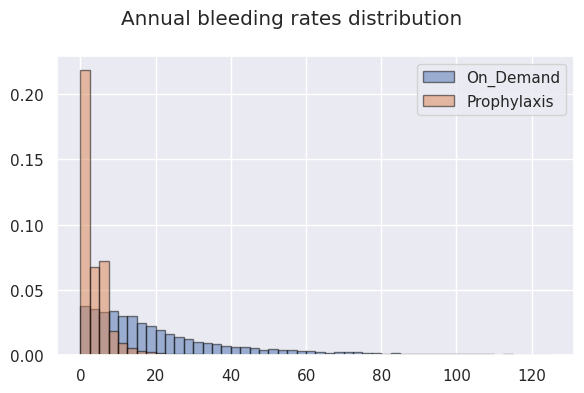

In [ ]:
# Short term simulation
from time import time
import matplotlib.pyplot as plt
import seaborn as sns

import model.types

start = time()
# Note: For the sake of statistical comparison n_samples should be in same size over different population in each treatment arms
on_demand_sampled_abr = psa.sample_population_abrs(
    treatment=model.types.Treatment.ON_DEMAND, n_samples=sobol_sample_size, visualize=False
)
prophylaxis_sampled_abr = psa.sample_population_abrs(
    treatment=model.types.Treatment.PROPHYLAXIS, n_samples=sobol_sample_size, visualize=False
)
exc_time = round((time() - start), 2)
logger.info(f"Sampling ABR values took {exc_time} seconds")
logger.info(f"Generated data length: {len(on_demand_sampled_abr)}")

# Drawing population ABR distribution
plt.figure(figsize=(6, 4))
plt.suptitle("Annual bleeding rates distribution")
on_demand_hist = plt.hist(
    on_demand_sampled_abr,
    50,
    range=(0, 125),
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="On_Demand",
)
prophylaxis_hist = plt.hist(
    prophylaxis_sampled_abr,
    50,
    range=(0, 125),
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="Prophylaxis",
)
plt.legend()
plt.tight_layout()

INFO: Patients average weight: 24.27 kg


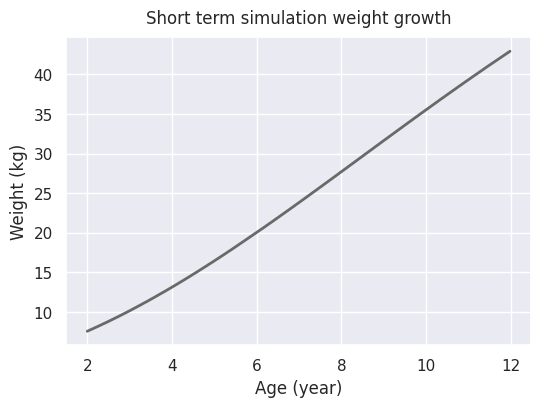

In [28]:
weights = [utils.cal_body_weight(n, b=ssp) for n in range(n_cycles)]
pairs: dict[int, float] = {(i + ssp): weight for i, weight in enumerate(weights)}
average_weight = np.mean(list(pairs.values()))

logger.info(f"Patients average weight: {round(average_weight, 2)} kg")

# Drawing patient weight growth graph
sns.set_theme()
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
X = np.array(list(pairs.keys()))
Y = np.array(list(pairs.values()))
ax.plot(X / constants.WOY, Y, color="dimgray", linestyle="-", linewidth=2)
text = ax.set_title("Short term simulation weight growth", pad=10)
y_text = ax.set_ylabel("Weight (kg)")
x_text = ax.set_xlabel("Age (year)")

In [ ]:
import model.markov_chain
import model.types


markov = mc.MarkovChains(
    chains=chains,
    entrance="Healthy",
    entrance_chain="main",
    steps=n_cycles,
    conditions=None,
)
logger.info(f"Starting simulations for {n_cycles} steps (weeks)")
od_sample = model.markov_chain.parallelize_markov_chain(
    simulation_name="on_demand",
    worker_inputs=[
        model.types.HemophiliaInput(
            treatment=model.types.Treatment.ON_DEMAND,
            abr=abr,
            ajbr=None,
            wbr=None,
            webr=None,
            wjbr=None,
        )
        for abr in on_demand_sampled_abr
    ],
    worker_func=psa.worker_function,
    markov_chain=markov,
)
prophylaxis_results = model.markov_chain.parallelize_markov_chain(
    simulation_name="prophylaxis",
    worker_inputs=[
        model.types.HemophiliaInput(
            treatment=model.types.Treatment.PROPHYLAXIS,
            abr=abr,
            ajbr=None,
            wbr=None,
            webr=None,
            wjbr=None,
        )
        for abr in prophylaxis_sampled_abr
    ],
    worker_func=psa.worker_function,
    markov_chain=markov,
)

INFO: Starting simulations for 520 steps (weeks)


In [ ]:
# Unwrap input outputs from results
on_demand_inputs, on_demand_outputs = od_sample
prophylaxis_inputs, prophylaxis_outputs = prophylaxis_results

In [16]:
SAMPLE_SIZE = len(on_demand_sampled_abr)
logger.info(f"{SAMPLE_SIZE:,} data generated to work with")

cols = list(psa.HemophiliaOutput.model_fields.keys())
cols.insert(0, "regimes")
cols.insert(1, "input_abr")

for key in ["arthropathy", "is_dead", "weights", "mean_weight", "person_year"]:
    cols.append(key)

logger.info("Dataframe Columns: \n {}".format(cols).replace(",", ",\n"))

INFO: 5,632 data generated to work with
INFO: Dataframe Columns: 
 ['regimes',
 'input_abr',
 'initial_state',
 'final_state',
 'steps',
 'path',
 'factor_consumption',
 'factor_costs',
 'annual_factor_consumption',
 'annual_factor_costs',
 'hemarthrosis',
 'qaly',
 'abr',
 'pettersson_score',
 'arthropathy',
 'is_dead',
 'weights',
 'mean_weight',
 'person_year']


In [ ]:
import pandas as pd
import numpy as np


def truncate_weights_at_death(sequences: list["str"]):
    death_indices = [
        i
        for i, state in enumerate(sequences)
        if state
        and any(
            "death" in str(s).lower()
            for s in (state if isinstance(state, (list, tuple)) else [state])
        )
    ]

    if death_indices:
        # Use the first death occurrence
        death_index = death_indices[0]
        return weights[: death_index + 1]  # Include the death state

    # If no death found, return full weights
    return weights


def to_stage(pettersson_score_sequence: list[int | float] | np.ndarray):
    if isinstance(pettersson_score_sequence, list):
        pettersson_score_sequence = np.array(pettersson_score_sequence)
    if len(pettersson_score_sequence.shape) > 1:
        raise ValueError(
            f"Pettersson score array should be 1-D, shape: {pettersson_score_sequence.shape}"
        )
    if np.all(pettersson_score_sequence == 0):
        return "healthy"
    max_score = pettersson_score_sequence.max()
    if max_score < 0:
        raise ValueError("Invalid pettersson score")
    if max_score > 28:
        return "severe"
    elif max_score > 5:
        return "moderate"
    elif max_score <= 5:
        return "mild"
    else:
        raise ValueError(f"No stage defined for pettersson score: {max_score}")


start = time()
on_demand_df = pd.DataFrame(
    columns=cols,
    data={
        "regimes": "on_demand",
        "initial_state": [op.initial_state for op in on_demand_outputs],
        "final_state": [op.final_state for op in on_demand_outputs],
        "steps": [op.steps for op in on_demand_outputs],
        "input_abr": [op["abr"] for op in on_demand_inputs],
        "abr": [op.abr for op in on_demand_outputs],
        "hemarthrosis": [op.hemarthrosis for op in on_demand_outputs],
        "factor_consumption": [op.factor_consumption for op in on_demand_outputs],
        "qaly": [op.qaly for op in on_demand_outputs],
        "factor_costs": [op.factor_costs for op in on_demand_outputs],
        "annual_factor_consumption": [
            op.annual_factor_consumption for op in on_demand_outputs
        ],
        "annual_factor_costs": [op.annual_factor_costs for op in on_demand_outputs],
        "arthropathy": [to_stage(op.pettersson_score) for op in on_demand_outputs],
        "pettersson_score": [op.pettersson_score for op in on_demand_outputs],
        "is_dead": [True if "Death" in op.path else False for op in on_demand_outputs],
        "path": [op.path for op in on_demand_outputs],
        "weights": [truncate_weights_at_death(op.path) for op in on_demand_outputs],
    },
)

# ---- Dependent columns assignment ----
mean_weight = lambda x: round(np.array(x).mean(), 2)  # noqa: E731
person_year = lambda x: round(len(x) / constants.WOY, 2)  # noqa: E731

on_demand_df["mean_weight"] = on_demand_df["weights"].apply(mean_weight)
on_demand_df["person_year"] = on_demand_df["weights"].apply(person_year)
exc_time = round((time() - start), 2)
logger.info(f"Loading on_demand data with pandas took {exc_time} seconds")

start = time()
prophylaxis_df = pd.DataFrame(
    data={
        "regimes": "prophylaxis",
        "input_abr": [op["abr"] for op in prophylaxis_inputs],
        "initial_state": [op.initial_state for op in prophylaxis_outputs],
        "final_state": [op.final_state for op in prophylaxis_outputs],
        "steps": [op.steps for op in prophylaxis_outputs],
        "abr": [op.abr for op in prophylaxis_outputs],
        "hemarthrosis": [op.hemarthrosis for op in prophylaxis_outputs],
        "factor_consumption": [op.factor_consumption for op in prophylaxis_outputs],
        "qaly": [op.qaly for op in prophylaxis_outputs],
        "factor_costs": [op.factor_costs for op in prophylaxis_outputs],
        "annual_factor_consumption": [
            op.annual_factor_consumption for op in prophylaxis_outputs
        ],
        "annual_factor_costs": [op.annual_factor_costs for op in prophylaxis_outputs],
        "pettersson_score": [op.pettersson_score for op in prophylaxis_outputs],
        "arthropathy": [to_stage(op.pettersson_score) for op in prophylaxis_outputs],
        "is_dead": [
            True if "Death" in op.path else False for op in prophylaxis_outputs
        ],
        "path": [op.path for op in prophylaxis_outputs],
        "weights": [truncate_weights_at_death(op.path) for op in prophylaxis_outputs],
    },
    columns=cols,
)
prophylaxis_df["mean_weight"] = prophylaxis_df["weights"].apply(mean_weight)
prophylaxis_df["person_year"] = prophylaxis_df["weights"].apply(person_year)
exc_time = round((time() - start), 2)
logger.info(f"loading prophylaxis data with pandas took {exc_time} seconds")

df_raw = pd.concat([on_demand_df, prophylaxis_df])

# ---- Preprocessing ----
unnecessary_columns = ["initial_state", "steps", "path", "weights", "pettersson_score"]
df = df_raw.drop(columns=unnecessary_columns)
df = df.apply(lambda x: round(x, 2) if pd.api.types.is_numeric_dtype(x) else x)
df[(df["is_dead"] == False)].head(n=5)  # noqa: E712


INFO: Loading on_demand data with pandas took 5.34 seconds
INFO: loading prophylaxis data with pandas took 5.5 seconds


,regimes,input_abr,final_state,factor_consumption,factor_costs,annual_factor_consumption,annual_factor_costs,hemarthrosis,qaly,abr,arthropathy,is_dead,mean_weight,person_year
0,on_demand,20.61,Hemarthrosis,397013.0,26974.12,39701.3,2697.41,19.3,7.26,18.9,moderate,False,24.27,10.0
1,on_demand,13.16,Hemarthrosis,259968.0,17662.92,25996.8,1766.29,11.6,7.67,11.4,moderate,False,24.27,10.0
3,on_demand,51.62,Hemarthrosis,937506.0,63696.65,93750.6,6369.67,49.6,6.23,49.5,severe,False,24.27,10.0
4,on_demand,51.50,Healthy,921776.0,62627.91,92177.6,6262.79,49.7,6.24,49.5,severe,False,24.27,10.0
5,on_demand,16.30,Healthy,318358.0,21630.09,31835.8,2163.01,15.1,7.51,15.5,moderate,False,24.27,10.0


In [32]:
df_alive = df[df["is_dead"] == False]  # noqa: E712
abs_diff = np.abs(df_alive["abr"] - df_alive["input_abr"])
f2 = lambda x: round(x, 2)  # noqa: E731
# Sums
logger.info(
    f"""
    Mean absolute differences of simulated annual bleeding rate vs model input abr value: {f2(abs_diff.mean())}, ({f2(abs_diff.std())})
    """
)

INFO: 
    Mean absolute differences of simulated annual bleeding rate vs model input abr value: 0.78, (1.18)
    


In [19]:
# TODO: Visualize model generated transition matrix, or store them as csv files

In [74]:
SIMULATED_YEARS = int(n_cycles / constants.WOY)
per_year = lambda x: x / SIMULATED_YEARS  # noqa: E731

MORT_RATE_OD = on_demand_df["is_dead"].mean() * 100
MORT_RATE_PRO = prophylaxis_df["is_dead"].mean() * 100
# Relative mortality reduction
RRR = (MORT_RATE_OD - MORT_RATE_PRO) / MORT_RATE_OD * 100
PREVENTED_DEATH = on_demand_df.is_dead.sum() - prophylaxis_df.is_dead.sum()
PREVENTED_DEATH_PER_1000P = PREVENTED_DEATH / SAMPLE_SIZE * 1000

ANNUAL_BLEED_PREVENTED = round(on_demand_df.abr.sum() - prophylaxis_df.abr.sum())
RELATIVE_ABR_REDUCTION = round(ANNUAL_BLEED_PREVENTED / on_demand_df.abr.sum() * 100)

# Factor consumption ratio
FCR = prophylaxis_df.factor_consumption.sum() / on_demand_df.factor_consumption.sum()

# Delta values
DC = f2(prophylaxis_df["factor_costs"].sum() - on_demand_df["factor_costs"].sum())
DQ = f2(prophylaxis_df["qaly"].sum() - on_demand_df["qaly"].sum())
LG = f2(prophylaxis_df["person_year"].sum() - on_demand_df["person_year"].sum())
ICER_QALY = f2(DC / DQ)
ICER_LG = f2(DC / LG)
ACCEPTABLE_EXPENDITURE = constants.WTP_THRESHOLD * (DQ)
NMB = f2(ACCEPTABLE_EXPENDITURE - DC)

logger.info(
    f"""
    Population size (simulations): {SAMPLE_SIZE}
    Simulation length (year): {SIMULATED_YEARS}
    Increased factor costs: ${round(DC):,}
    Increased QALY: {DQ:,}
    Relative ABR reduction: {f2(RELATIVE_ABR_REDUCTION)}%
    Relative mortality reduction: {round(RRR)}%
    Number of death prevented (per 1000 person): {round(PREVENTED_DEATH_PER_1000P)}
    Life years gained: {LG:,}
    
    [Annual]
    Annual increased factor cost: ${round(per_year(DC)):,}
    Annual bleeds prevented: {ANNUAL_BLEED_PREVENTED:,}
    
    [Economic indicators]
    Factor consumption: {f2(FCR)} folds increase
    Cost per bleed prevented: ${round(per_year(DC) / ANNUAL_BLEED_PREVENTED)}
    Incremental cost effectiveness ratio (DC/QALY): ${int(ICER_QALY):,}
    Incremental cost effectiveness ratio (DC/LYG): ${int(ICER_LG):,}
    New monetary benefits: ${round(NMB):,}
    
    Conclusion: Intervention {"was not" if NMB < 0 else "was"} cost effective
    """
)

INFO: 
    Population size (simulations): 5632
    Simulation length (year): 10
    Increased factor costs: $497,637,733
    Increased QALY: 20,864.86
    Relative ABR reduction: 80%
    Relative mortality reduction: 66%
    Number of death prevented (per 1000 person): 398
    Life years gained: 12,644.24
    
    [Annual]
    Annual increased factor cost: $49,763,773
    Annual bleeds prevented: 134,996
    
    [Economic indicators]
    Factor consumption: 3.12 folds increase
    Cost per bleed prevented: $369
    Incremental cost effectiveness ratio (DC/QALY): $23,850
    Incremental cost effectiveness ratio (DC/LYG): $39,356
    New monetary benefits: $-198,973,954
    
    Conclusion: Intervention was not cost effective
    


In [ ]:
per_kg = lambda x: x / np.array(weights).mean()  # noqa: E731
logger.info(
    f"""
    [On Demand]
    ABR: {f2(on_demand_df.abr.mean())} ({f2(on_demand_df.abr.std())})
    Mean factor consumption per mean weight (IU/KG): {round(per_kg(on_demand_df.annual_factor_consumption.mean())):,} ({round(per_kg(on_demand_df.annual_factor_consumption.std())):,})
    Death (includes natural cause of death): {f2(MORT_RATE_OD)}%
    Joint outcome:
        - Healthy: {round(f2(on_demand_df.arthropathy.str.count("healthy").mean()) * 100)}%
        - Mild arthropathy: {round(f2(on_demand_df.arthropathy.str.count("mild").mean()) * 100)}%
        - Moderate arthropathy: {round(f2(on_demand_df.arthropathy.str.count("moderate").mean()) * 100)}%
        - Severe arthropathy: {round(f2(on_demand_df.arthropathy.str.count("severe").mean()) * 100)}%
    
    [Prophylaxis]
    ABR: {f2(prophylaxis_df.abr.mean())} ({f2(prophylaxis_df.abr.std())})
    Mean factor consumption per mean weight (IU/KG): {round(per_kg(prophylaxis_df.annual_factor_consumption.mean())):,} ({round(per_kg(prophylaxis_df.annual_factor_consumption.std())):,})
    Death (includes natural cause of death): {f2(MORT_RATE_PRO)}%
    Joint outcome:
        - Healthy: {round(f2(prophylaxis_df.arthropathy.str.count("healthy").mean()) * 100)}%
        - Mild arthropathy: {round(f2(prophylaxis_df.arthropathy.str.count("mild").mean()) * 100)}%
        - Moderate arthropathy: {round(f2(prophylaxis_df.arthropathy.str.count("moderate").mean()) * 100)}%
        - Severe arthropathy: {round(f2(prophylaxis_df.arthropathy.str.count("severe").mean()) * 100)}%
    """
)

# Burden of disease

INFO: 
    [On Demand]
    ABR: 15.04 (14.74)
    Mean factor consumption per mean weight (IU/KG): 1,261 (1,293)
    Death (includes natural cause of death): 30.2%
    Joint outcome:
        - Healthy: 6%
        - Mild arthropathy: 37%
        - Moderate arthropathy: 53%
        - Severe arthropathy: 4%
    
    [Prophylaxis]
    ABR: 3.06 (3.78)
    Mean factor consumption per mean weight (IU/KG): 3,940 (944)
    Death (includes natural cause of death): 10.3%
    Joint outcome:
        - Healthy: 35%
        - Mild arthropathy: 59%
        - Moderate arthropathy: 6%
        - Severe arthropathy: 0%
    


INFO: Bootstrapping model outputs to calculate ICER IQR and STD
INFO: Bootstrapping with 5000 iterations took 15.41 seconds
INFO: IQR: $657.59


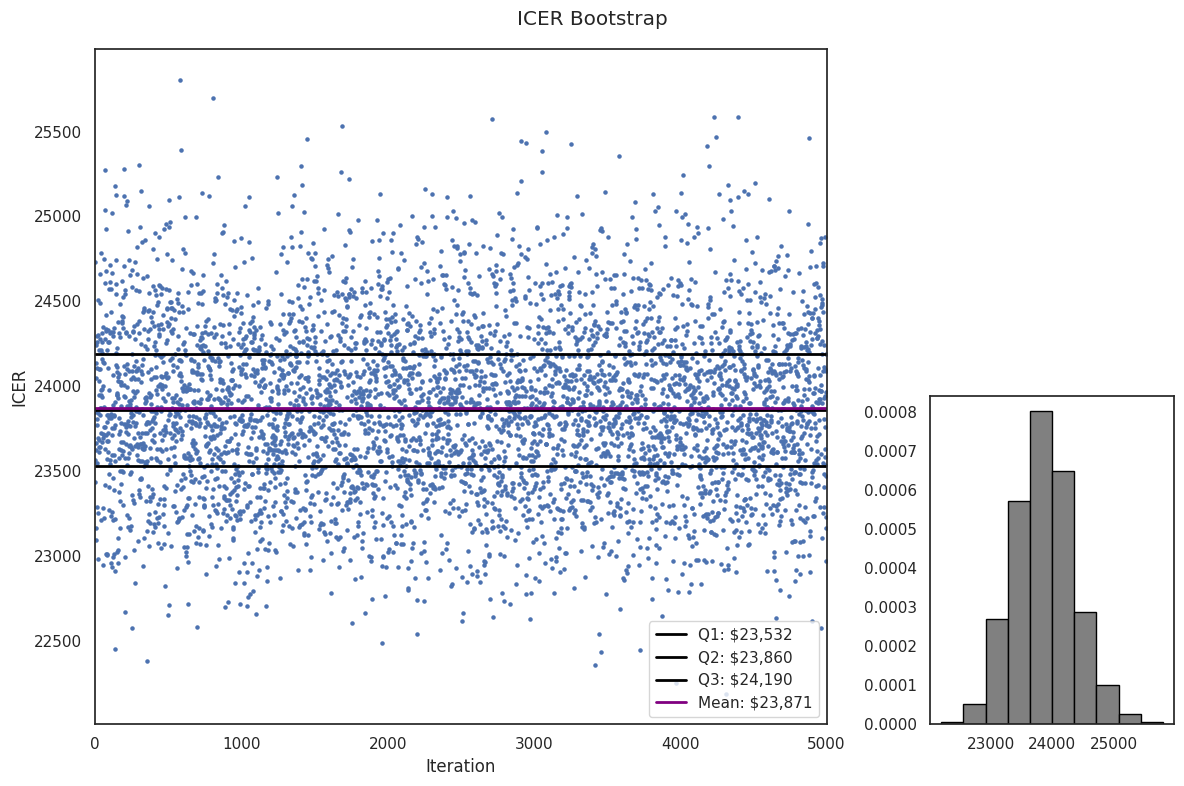

In [ ]:
from matplotlib.gridspec import GridSpec

logger.info("Bootstrapping model outputs to calculate ICER IQR and STD")
ICER_LIST = []
BOOTSTRAP_ITER = 5000
start = time()
for _ in range(BOOTSTRAP_ITER):
    od_sample = on_demand_df.sample(n=SAMPLE_SIZE, replace=True)
    pro_sample = prophylaxis_df.sample(n=SAMPLE_SIZE, replace=True)
    DC = pro_sample["factor_costs"].sum() - od_sample["factor_costs"].sum()
    DQ = pro_sample["qaly"].sum() - od_sample["qaly"].sum()
    if np.isfinite(DC) and np.isfinite(DQ) and DQ != 0:
        ICER_LIST.append(DC / DQ)
exc_time = round(time() - start, 2)
logger.info(f"Bootstrapping with {BOOTSTRAP_ITER} iterations took {exc_time} seconds")

ICER_LIST = np.array(ICER_LIST)
pairs = {i: y for i, y in enumerate(ICER_LIST)}
X = list(pairs.keys())
Y = list(pairs.values())

sns.set_theme(style="white")
fig = plt.figure(figsize=(12, 8))

gs = GridSpec(2, 2, width_ratios=(3, 1), height_ratios=(1, 1))
scatter = fig.add_subplot(gs[:, :-1])
hist = fig.add_subplot(gs[-1, -1])
scatter.scatter(X, Y, s=5)
hist.hist(Y, color="gray", density=True, edgecolor="black")


Q1 = np.percentile(ICER_LIST, 25).astype(float)
Q2 = np.percentile(ICER_LIST, 50).astype(float)
Q3 = np.percentile(ICER_LIST, 75).astype(float)
ICERS_MEAN = ICER_LIST.mean()

scatter.axhline(Q1, color="black", linewidth=2, label=f"Q1: ${round(Q1):,}")
scatter.axhline(Q2, color="black", linewidth=2, label=f"Q2: ${round(Q2):,}")
scatter.axhline(Q3, color="black", linewidth=2, label=f"Q3: ${round(Q3):,}")
scatter.axhline(
    ICERS_MEAN,
    color="purple",
    linewidth=2,
    label=f"Mean: ${round(ICERS_MEAN):,}",
)
scatter.set_xlim(left=0, right=ICER_LIST.shape[0])
scatter.set_ylabel("ICER")
scatter.set_xlabel("Iteration")
scatter.legend()
fig.suptitle("ICER Bootstrap")
fig.tight_layout()

logger.info(f"IQR: ${(Q3 - Q1):.2f}")

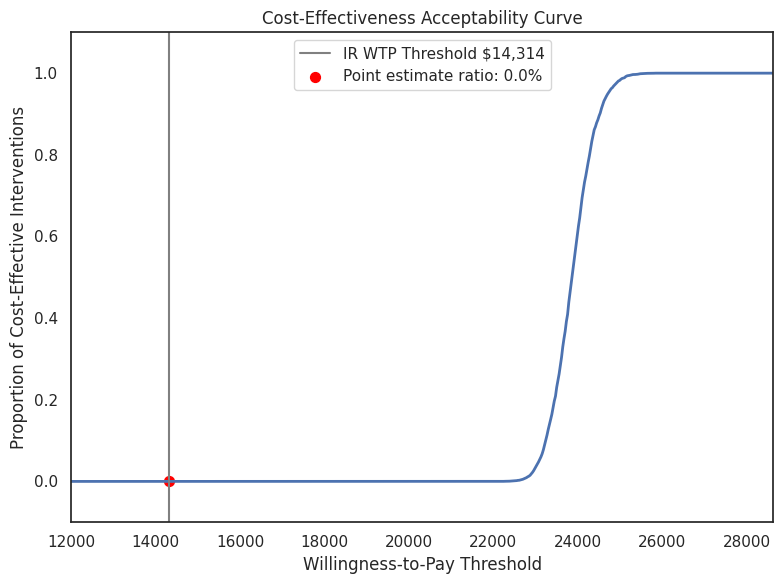

In [91]:
# Create WTP thresholds - consider making the upper bound more flexible
max_threshold = constants.WTP_THRESHOLD * 2
X = np.linspace(start=0, stop=max_threshold, num=1000)

Y = []

for threshold in X:
    # Below the current threshold
    cost_effective_count = np.sum(ICER_LIST <= threshold)  # type: ignore
    ratio = cost_effective_count / len(ICER_LIST)
    Y.append(ratio)

icer_ratio = np.sum((ICER_LIST <= constants.WTP_THRESHOLD)) / len(ICER_LIST)  # type: ignore
# Create the plot
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(X, Y, linewidth=2)
ax.axvline(
    x=constants.WTP_THRESHOLD,
    color="gray",
    label=f"IR WTP Threshold ${round(constants.WTP_THRESHOLD):,}",
)
ax.scatter(
    x=constants.WTP_THRESHOLD,
    y=icer_ratio,
    color="red",
    s=50,
    label=f"Point estimate ratio: {round(icer_ratio, 2)}%",
)
ax.set_xlabel("Willingness-to-Pay Threshold")
ax.set_ylabel("Proportion of Cost-Effective Interventions")
ax.set_title("Cost-Effectiveness Acceptability Curve")
ax.set_xlim(12000, max_threshold)
ax.set_ylim(-0.1, 1.1)
ax.legend()
fig.tight_layout()

INFO: ICER calculation took: 0.0 seconds


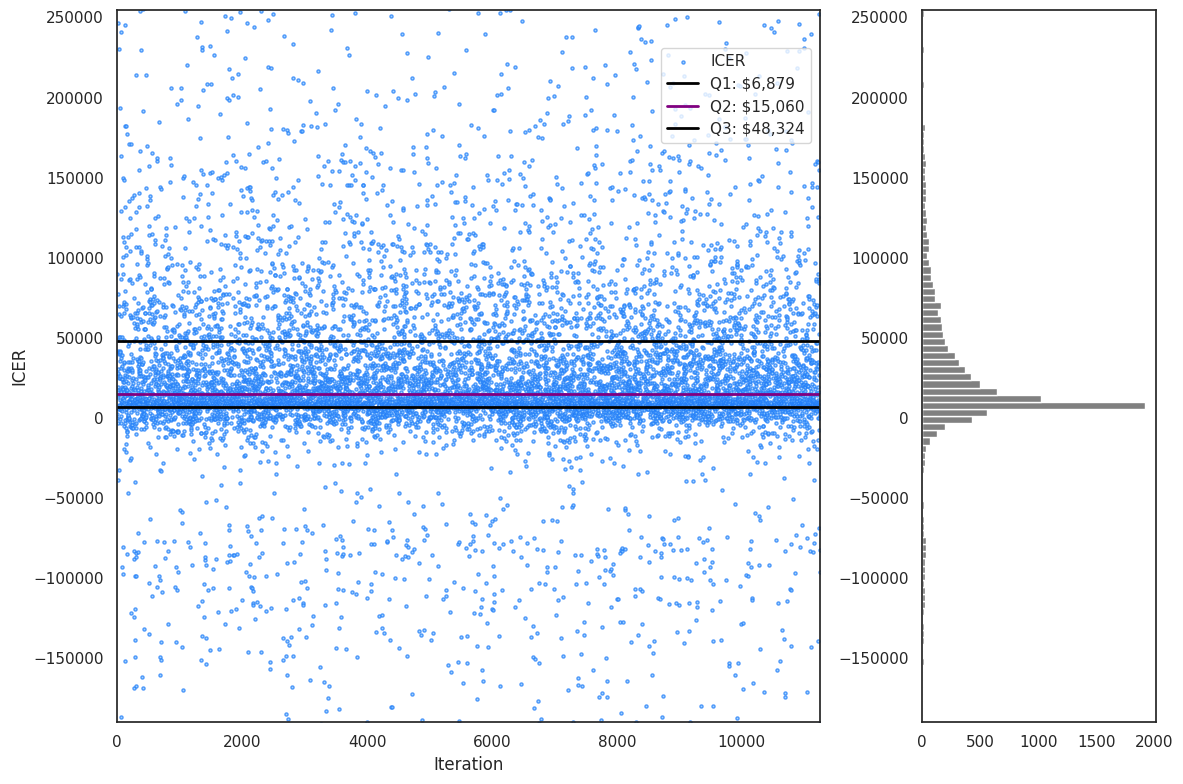

In [107]:
# sns.set_theme(style="darkgrid", rc={"axes.spines.right": False, "axes.spines.top": False})
sns.set_theme(style="white")
start = time()
DC = prophylaxis_df.factor_costs.to_numpy() - on_demand_df.factor_costs.to_numpy()
DQ = prophylaxis_df.qaly.to_numpy() - on_demand_df.qaly.to_numpy()

valid_mask = np.isfinite(DQ) & np.isfinite(DC) & (DQ != 0)

ICER_LIST = DC[valid_mask] / DQ[valid_mask]

logger.info(f"ICER calculation took: {round(time() - start, 2)} seconds")

fig = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 2, width_ratios=(3, 1), height_ratios=(1, 1))

scatter = fig.add_subplot(gs[:, :-1])
hist = fig.add_subplot(gs[:, -1])

scatter.scatter(
    x=[i for i in range(len(ICER_LIST))],
    y=ICER_LIST,
    alpha=0.75,
    s=5,
    color="#88C6FF",
    edgecolors="#237FF8",
)
scatter.set_ylabel("ICER")
scatter.set_xlabel("Iteration")

Q1 = np.percentile(ICER_LIST, 25).astype(float)
Q2 = np.percentile(ICER_LIST, 50).astype(float)
Q3 = np.percentile(ICER_LIST, 75).astype(float)

P5 = np.percentile(ICER_LIST, 5).astype(float)
P95 = np.percentile(ICER_LIST, 95).astype(float)
TRUNC_ICERS = ICER_LIST[(ICER_LIST >= P5) & (ICER_LIST <= P95)]
hist.hist(TRUNC_ICERS, bins=100, color="gray", orientation="horizontal")
hist.set_ylim(bottom=P5, top=P95)

scatter.axhline(Q1, color="black", linewidth=2)
scatter.axhline(Q2, color="purple", linewidth=2)
scatter.axhline(Q3, color="black", linewidth=2)
scatter.set_xlim(left=0, right=ICER_LIST.shape[0])
scatter.set_ylim(bottom=P5, top=P95)
fig.legend(
    [
        "ICER",
        f"Q1: ${int(Q1):,}",
        f"Q2: ${int(Q2):,}",
        f"Q3: ${int(Q3):,}",
    ],
    loc="upper center",
    bbox_to_anchor=(0.62, 0.94),
)
fig.tight_layout()

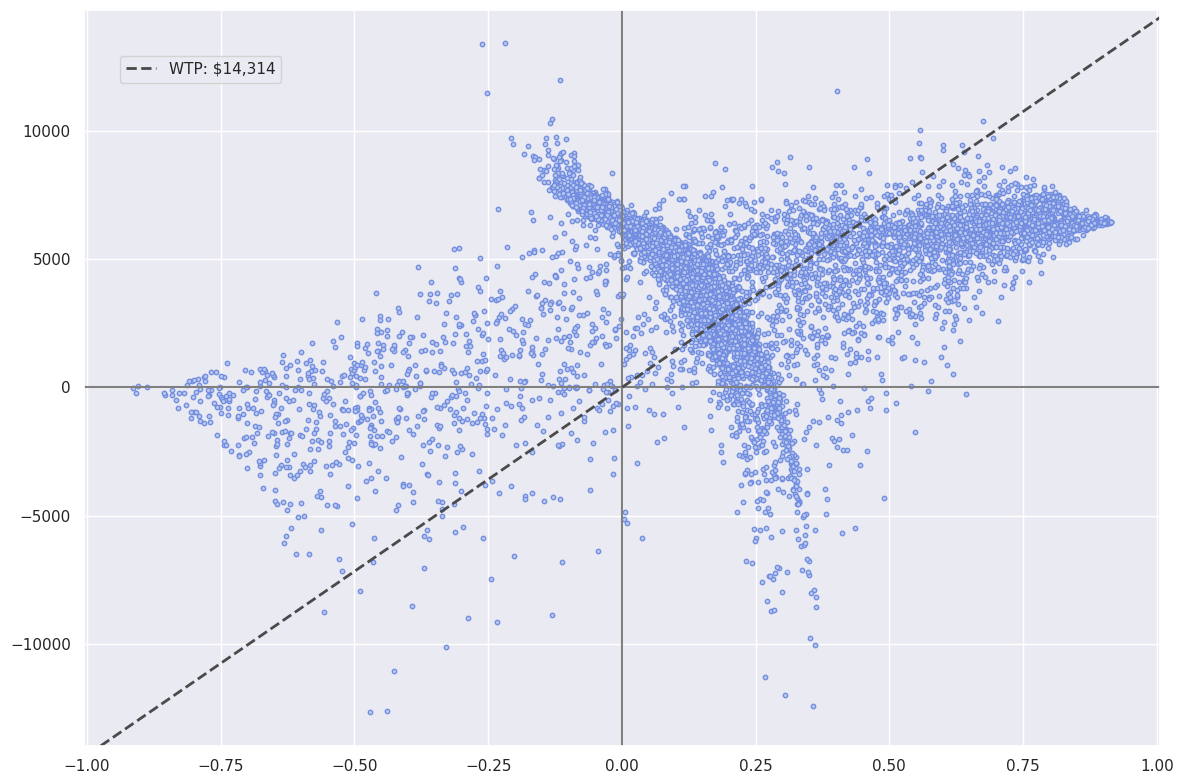

In [112]:
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.scatter(x=per_year(DQ), y=per_year(DC), s=10, edgecolor="#738EE0", color="#BACAED")
ax.axvline(x=0, color="gray")
ax.axhline(y=0, color="gray")
ax.axline(
    (0, 0),
    slope=constants.WTP_THRESHOLD,
    color="#4A4A4A",
    linestyle="--",
    linewidth=2,
    label=f"WTP: ${round(constants.WTP_THRESHOLD):,}",
)
fig.legend(loc="upper left", bbox_to_anchor=(0.10, 0.93))
fig.tight_layout()

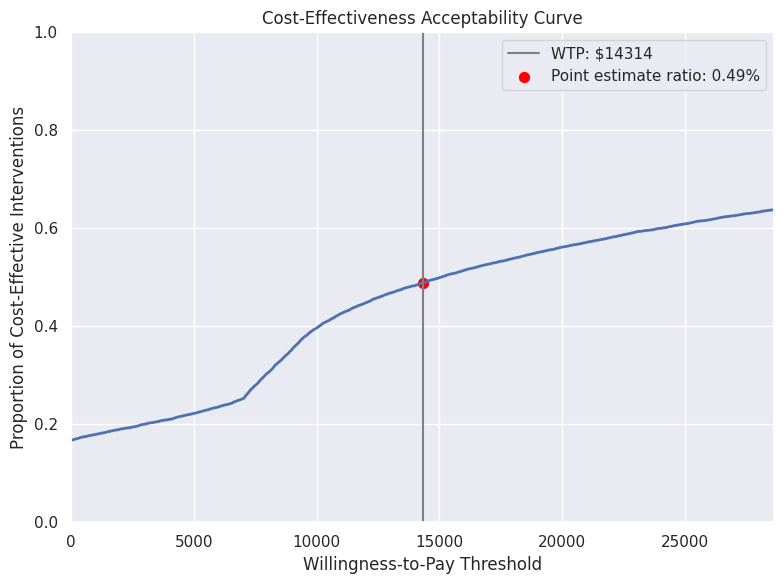

In [117]:
# Create WTP thresholds - consider making the upper bound more flexible
max_threshold = constants.WTP_THRESHOLD * 2
X = np.linspace(start=0, stop=max_threshold, num=1000)

Y = []
for threshold in X:
    # Below the current threshold
    cost_effective_count = np.sum(ICER_LIST <= threshold)
    ratio = cost_effective_count / len(ICER_LIST)
    Y.append(ratio)
icer_ratio = np.sum(ICER_LIST <= constants.WTP_THRESHOLD) / len(ICER_LIST)
# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(X, Y, linewidth=2)
ax.axvline(
    x=constants.WTP_THRESHOLD,
    color="gray",
    label=f"WTP: ${round(constants.WTP_THRESHOLD)}",
)
ax.scatter(
    x=constants.WTP_THRESHOLD,
    y=icer_ratio,
    color="red",
    s=50,
    label=f"Point estimate ratio: {round(icer_ratio, 2)}%",
)
ax.set_xlabel("Willingness-to-Pay Threshold")
ax.set_ylabel("Proportion of Cost-Effective Interventions")
ax.set_title("Cost-Effectiveness Acceptability Curve")
ax.set_xlim(0, max_threshold)
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()

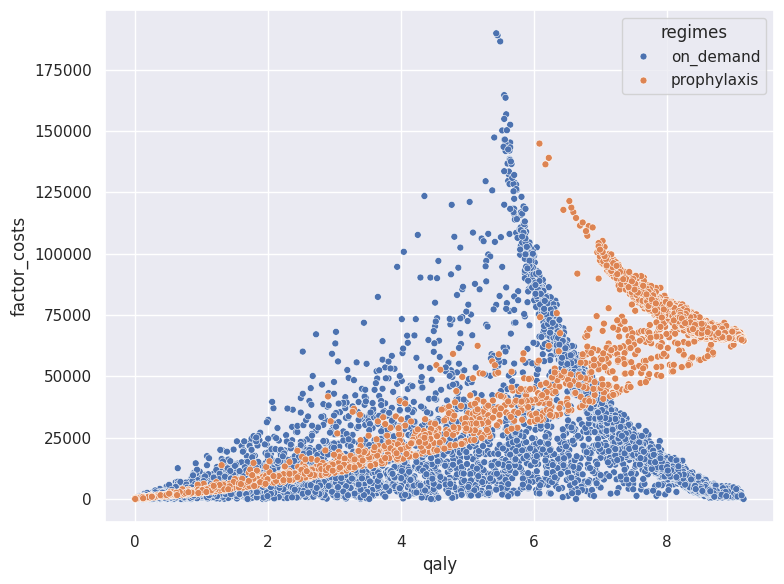

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(df, x="qaly", y="factor_costs", hue="regimes", s=25)
# TODO: Distribution
plt.tight_layout()

In [ ]:
# Value to report:
# Report no. of factor viii infusions [ ]
# Report annual cost of factor viii / kg [ ]
# Report annual joint hemorrhages [ ]
# Budget impact [ ]
# Onset of arthropathy [ ]
# Number of treated bleeds [ ]
# Burden of disease [√]
# Report no. of factor viii unit infused [√]
# Report no. of factor viii unit infused per kg [√]
# Report annual bleeding rate [√]
# Report quality adjusted life year [√]
# Report Incremental cost effectiveness ratio [√]
# Report Net monetary benefit [√]